# Does a reinforcement-learning agent rediscover blackjack basic strategy?
### A policy-level audit of tabular Monte-Carlo control

An agent learns blackjack from nothing but the win/loss at the end of each hand. *Basic strategy* — the
provably-optimal action in every situation — is our ground-truth answer key. This notebook audits the
**learned policy against that key**: not whether the agent wins at the right rate, but **where its
decisions differ from optimal, and why.**

**The finding, up front.** The agent reaches near-optimal play (house edge ≈ 0.5%, vs an optimal
≈ 0.45–0.5%) and reproduces the large majority of basic strategy. The disagreements are *not* spread
evenly — they concentrate in the rarest, closest decisions (soft doubles, low pairs). Most of that
residual is the **cost of learning from experience**: situations the agent rarely meets, it never learns
to play well. A smaller part is irreducible — genuine ties where "wrong" costs almost nothing.

**Method discipline.** Every claim is made to prove itself: agreement is reported visit-weighted *and*
unweighted; disagreements are separated by *severity*, not merely counted; runs are ranked only on
estimates whose error bars don't overlap.

## 1. Setup

In [25]:
import json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
%matplotlib inline

RUNS = "../runs"

def pick(**crit):
    """Newest saved run whose config matches the given fields (robust to dir names)."""
    best = None
    for p in sorted(glob.glob(f"{RUNS}/*/record.json")):
        cfg = json.load(open(p))["config"]
        def norm(k):
            v = cfg.get(k)
            if k == "with_splits":
                return bool(v)
            if k == "epsilon_schedule":
                return v or "constant"   # None == constant (pre-schedule runs)
            return v
        if all(norm(k) == v for k, v in crit.items()):
            best = p
    if best is None:
        raise FileNotFoundError(f"no run matches {crit}")
    return json.load(open(best))

def cells_of(record):
    """Policy-diff cells as a DataFrame, with ev_gap and a readable kind label."""
    df = pd.DataFrame(record["diff"]["cells"])
    if "can_split" not in df:
        df["can_split"] = False
    df["can_split"] = df["can_split"].fillna(False).astype(bool)
    df["ev_gap"] = (df["agent_q"] - df["basic_q"]).abs()
    df["kind"] = ["pair" if cs else ("soft" if s else "hard")
                  for cs, s in zip(df["can_split"], df["is_soft"])]
    return df

def run_label(record):
    c = record["config"]
    sched = c.get("epsilon_schedule") or "constant"
    eps = (f"eps {c['epsilon']}" if sched == "constant"
           else f"{sched} {c.get('epsilon_start')}->{c.get('epsilon_end')}")
    alpha = f", a={c['step_size']}" if c.get("step_size") else ""
    splits = ", +splits" if c.get("with_splits") else ""
    return f"{eps}{alpha}{splits}"

# Load the runs this notebook references (selected by config, not by folder name).
baseline = pick(epsilon=0.1,  epsilon_schedule="constant", with_splits=False)
eps03    = pick(epsilon=0.3,  epsilon_schedule="constant", with_splits=False)
eps005   = pick(epsilon=0.05, epsilon_schedule="constant", with_splits=False)
decay    = pick(epsilon_schedule="linear", step_size=0.001, with_splits=False)
split    = pick(with_splits=True)
for nm, r in [("baseline", baseline), ("eps0.3", eps03), ("eps0.05", eps005),
              ("decay+a", decay), ("split", split)]:
    print(f"{nm:9s} -> {run_label(r):34s} ({r['config']['num_episodes']:,} episodes)")

baseline  -> eps 0.1                            (5,000,000 episodes)
eps0.3    -> eps 0.3                            (5,000,000 episodes)
eps0.05   -> eps 0.05                           (5,000,000 episodes)
decay+a   -> linear 0.3->0.0, a=0.001           (5,000,000 episodes)
split     -> linear 0.3->0.0, a=0.001, +splits  (5,000,000 episodes)


In [26]:
PAIR_LABEL = {(4, False): "2,2", (6, False): "3,3", (8, False): "4,4", (10, False): "5,5",
              (12, False): "6,6", (14, False): "7,7", (16, False): "8,8", (18, False): "9,9",
              (20, False): "T,T", (12, True): "A,A"}
PAIR_ORDER = ["2,2", "3,3", "4,4", "5,5", "6,6", "7,7", "8,8", "9,9", "T,T", "A,A"]

def plot_policy_heatmap(df, title=""):
    """Learned-vs-basic heatmap. Two panels (hard/soft); adds a third (pairs) when present."""
    CATS = ["agree", "near_equal_ev", "genuine_disagreement", "under_visited"]
    COLORS = {"agree": "#cdebc5", "near_equal_ev": "#fde08a",
              "genuine_disagreement": "#f3a3a3", "under_visited": "#d9d9d9"}
    cat_i = {c: i for i, c in enumerate(CATS)}
    cmap = ListedColormap([COLORS[c] for c in CATS])
    ACT = {"hit": "H", "stand": "S", "double": "D", "split": "P", "surrender": "R"}
    ups = list(range(2, 12))

    def grid(ax, d, sub, field, order):
        rows = [r for r in order if r in set(d[field])]
        g = np.full((len(rows), len(ups)), np.nan)
        for _, r in d.iterrows():
            if r[field] not in rows:
                continue
            i, j = rows.index(r[field]), ups.index(r["dealer_upcard"])
            g[i, j] = cat_i[r["category"]]
            lab = ACT[r["agent_action"]]
            if r["agent_action"] != r["basic_action"]:
                lab = f"{ACT[r['agent_action']]}\u2192{ACT[r['basic_action']]}"
            ax.text(j, i, lab, ha="center", va="center", fontsize=7)
        ax.imshow(g, cmap=cmap, vmin=0, vmax=len(CATS) - 1, aspect="auto")
        ax.set_xticks(range(len(ups))); ax.set_xticklabels(ups)
        ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows)
        ax.set_xlabel("dealer upcard"); ax.set_title(sub)

    nonpair = df[~df["can_split"]]
    panels = [(nonpair[~nonpair["is_soft"]], "Hard totals", "player_value",
               sorted(nonpair[~nonpair["is_soft"]]["player_value"].unique())),
              (nonpair[nonpair["is_soft"]], "Soft totals", "player_value",
               sorted(nonpair[nonpair["is_soft"]]["player_value"].unique()))]
    if df["can_split"].any():
        pr = df[df["can_split"]].copy()
        pr["pair"] = [PAIR_LABEL.get((int(v), bool(s)), str(v))
                      for v, s in zip(pr["player_value"], pr["is_soft"])]
        panels.append((pr, "Pairs", "pair", [p for p in PAIR_ORDER if p in set(pr["pair"])]))

    fig, axes = plt.subplots(1, len(panels), figsize=(6.2 * len(panels), 7))
    axes = np.atleast_1d(axes)
    for ax, (d, nm, f, o) in zip(axes, panels):
        grid(ax, d, nm, f, o)
    axes[0].set_ylabel("player total / pair")
    fig.legend(handles=[Patch(facecolor=COLORS[c], label=c) for c in CATS],
               loc="lower center", ncol=4)
    fig.suptitle(f"Learned policy vs basic strategy  {title}".strip())
    plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

## 2. The question, and the method

The agent is a tabular Monte-Carlo control learner: it plays full hands, observes only the terminal
win/loss, and updates an action-value estimate `Q(state, action)` for every decision it made. Its
*greedy* policy — the highest-valued action per state — is what we audit. Basic strategy is the
exhaustively-computed optimum, so disagreement is meaningful: it is the agent falling short of a known
answer, not two opinions differing.

For each cell (player total × dealer upcard) we compare the agent's greedy action to basic strategy and
classify it: **agree**, **near-equal-EV** (the two actions are within a small value tolerance — a true
tie), **genuine disagreement** (well-visited and the actions differ in value), or **under-visited**
(too few samples to trust).

**One technical note, because it's a common trap.** This comparison is computed from the agent's
**trained Q-table and its training visit counts** — how often each (state, action) was actually
experienced across the 5M training hands. It does *not* depend on the separate house-edge evaluation
(the 200k/1M-hand simulations used only to measure the edge). A cell's label is therefore a property of
the *trained policy* and does **not** shift if we change the size of the edge evaluation.

## 3. The finding is localization, not the aggregate

"92.5% agreement" is true and nearly useless: it pools decisions the agent nails (stand on hard 20)
with the few it struggles with. The structure appears the moment we *condition* on the type of
decision.

In [27]:
b = cells_of(baseline)
b["involves_double"] = b["agent_action"].eq("double") | b["basic_action"].eq("double")
genuine = lambda s: (s["category"] == "genuine_disagreement").mean()

print(f"pooled agreement (visit-weighted): {baseline['diff']['agreement_weighted']:.1%}")
print(f"pooled agreement (unweighted):     {(b['category'] == 'agree').mean():.1%}\n")
print("P(genuine disagreement) conditioned on decision type:")
print(f"  hard totals : {genuine(b[~b.is_soft & ~b.can_split]):.1%}")
print(f"  soft totals : {genuine(b[b.is_soft & ~b.can_split]):.1%}")
print(f"  doubling in play : {genuine(b[b.involves_double]):.1%}")

pooled agreement (visit-weighted): 94.0%
pooled agreement (unweighted):     92.5%

P(genuine disagreement) conditioned on decision type:
  hard totals : 1.7%
  soft totals : 12.0%
  doubling in play : 27.1%


Disagreement is roughly **2% on hard totals, 12% on soft totals, and 27% wherever doubling is an
option.** The agent has essentially *learned* hard-total play; its gaps live almost entirely in the
soft and doubling decisions — precisely the situations that arise least often. This localization, not
the pooled 92.5%, is the result.

## 4. The disagreements — and their severity

Counting disagreements invites two mistakes, both created by leaning on a single hard threshold
(`ev_gap > 0.02`):

- **A knife-edge on the most important cell.** Hard 16 vs dealer 10 — the most famously-balanced
  decision in the game, ~166k visits — lands at `ev_gap ≈ 0.0211`, one thousandth over the line. By its
  own estimated value it is a tie; labelling it "genuine" is an artifact of the cutoff.
- **A severity-blind bucket.** Genuine `ev_gap`s span 20× (0.021 → 0.407). A raw count treats a
  coin-flip and a real blunder as equal.

So we report the **distribution and a severity tier**, not a headline count.

In [28]:
gd = b[b.category == "genuine_disagreement"].copy()
gd["severity"] = pd.cut(gd["ev_gap"], [0, 0.05, 0.15, 1.0],
                        labels=["near-tie (<0.05)", "moderate", "severe (>0.15)"])
print("genuine disagreements:", len(gd))
print("ev_gap distribution:")
print(gd["ev_gap"].describe()[["min", "25%", "50%", "75%", "max"]].round(3).to_string(), "\n")
print("by severity:\n", gd["severity"].value_counts().sort_index().to_string(), "\n")
show = gd.sort_values("ev_gap")[["kind", "player_value", "is_soft", "dealer_upcard",
                                 "visits", "agent_action", "basic_action", "ev_gap"]]
show.round(3)

genuine disagreements: 15
ev_gap distribution:
min    0.021
25%    0.035
50%    0.046
75%    0.102
max    0.407 

by severity:
 severity
near-tie (<0.05)    8
moderate            5
severe (>0.15)      2 



,kind,player_value,is_soft,dealer_upcard,visits,agent_action,basic_action,ev_gap
93,soft,12,True,5,2136,hit,double,0.021
168,hard,16,False,10,166610,stand,hit,0.021
134,soft,14,True,6,4990,hit,double,0.027
190,soft,17,True,2,6726,double,hit,0.032
44,hard,8,False,6,11757,double,hit,0.039
174,soft,16,True,6,5472,hit,double,0.043
113,soft,13,True,5,4827,hit,double,0.046
79,hard,11,False,11,14996,double,hit,0.046
210,soft,18,True,2,6835,double,stand,0.071
219,soft,18,True,11,4853,stand,hit,0.095


The distribution tells the real story: a cluster of **near-ties** (including the famous hard-16-vs-10),
a body of **moderate** gaps, and a short **tail** of larger ones. One interpretive caution that the
severity view makes visible: a *large* gap usually means the agent's alternative action was badly
under-sampled and therefore mis-valued — so large gaps are often themselves a *coverage* symptom, not a
confidently-wrong-but-well-learned choice. That is what the next section tests directly.

## 5. Mechanism — exploration starvation vs over-valuation

Two distinct things produce a wrong greedy action: the *right* action was **under-explored** (tried too
rarely to be valued correctly), or a *wrong* action was **over-valued** by lucky early returns that a
sample-average can't forget. We can tell them apart by counting how often each action was actually tried
in the disagreement cells.

In [29]:
qt = pd.DataFrame(baseline["qtable"])

def tries(row, action):
    m = ((qt.player_value == row.player_value) & (qt.is_soft == row.is_soft)
         & (qt.dealer_upcard == row.dealer_upcard) & (qt.action == action))
    if "can_split" in qt:
        m &= (qt.can_split == row.can_split)
    s = qt[m]
    return int(s["n"].iloc[0]) if len(s) else 0

mech = gd.copy()
mech["n_agent"] = [tries(r, r.agent_action) for r in gd.itertuples()]
mech["n_basic"] = [tries(r, r.basic_action) for r in gd.itertuples()]
mech["basic_share"] = (mech["n_basic"] / (mech["n_agent"] + mech["n_basic"])).round(2)
mech.sort_values("basic_share")[["kind", "player_value", "is_soft", "dealer_upcard",
    "agent_action", "basic_action", "n_agent", "n_basic", "basic_share", "ev_gap"]].round(3)

,kind,player_value,is_soft,dealer_upcard,agent_action,basic_action,n_agent,n_basic,basic_share,ev_gap
114,soft,13,True,6,hit,double,4427,150,0.03,0.148
172,soft,16,True,4,hit,double,4994,173,0.03,0.407
214,soft,18,True,6,stand,double,6392,207,0.03,0.099
113,soft,13,True,5,hit,double,4064,171,0.04,0.046
174,soft,16,True,6,hit,double,5052,184,0.04,0.043
168,hard,16,False,10,stand,hit,156031,7489,0.05,0.021
219,soft,18,True,11,stand,hit,4418,287,0.06,0.095
134,soft,14,True,6,hit,double,4529,303,0.06,0.027
212,soft,18,True,4,stand,double,5537,404,0.07,0.105
93,soft,12,True,5,hit,double,1788,188,0.10,0.021


Where `basic_share` is low, the *correct* action was barely tried — the agent never gathered the
evidence to value it. This is exploration starvation, and it dominates the doubling cells: doubling is
explored rarely under low ε, so its value stays pessimistic and the agent declines it. The fix is not
"explore more everywhere" (the next section shows why) but to schedule exploration and weight recent
experience.

## 6. The exploration–bias tradeoff: the residual *relocates*

This is the central result, and it is easy to miss. Raising ε does **not** shrink the disagreement — it
**moves** it. We compare, cell by cell, whether the agent matched basic strategy at ε=0.1 versus ε=0.3.

In [30]:
def match_series(rec):
    d = cells_of(rec)
    d["match"] = d.agent_action == d.basic_action
    return d.set_index(["player_value", "is_soft", "dealer_upcard"])["match"]

m1, m3 = match_series(baseline), match_series(eps03)
common = m1.index.intersection(m3.index)
worse  = int((m1.loc[common] & ~m3.loc[common]).sum())   # matched at 0.1, not at 0.3
better = int((~m1.loc[common] & m3.loc[common]).sum())   # matched at 0.3, not at 0.1
print(f"shared cells: {len(common)}")
print(f"  matched basic at eps0.1 but NOT at eps0.3  (got worse): {worse}")
print(f"  matched basic at eps0.3 but NOT at eps0.1  (got better): {better}")
print(f"  net change: {better - worse:+d}   -> the error largely RELOCATES, not resolves")

shared cells: 280
  matched basic at eps0.1 but NOT at eps0.3  (got worse): 12
  matched basic at eps0.3 but NOT at eps0.1  (got better): 11
  net change: -1   -> the error largely RELOCATES, not resolves


More exploration buys coverage of the rare cells **at the cost of biasing the common ones**: an
on-policy value reflects a behavior policy that now plays badly 30% of the time. Roughly as many cells
get worse as get better — the residual moves, it doesn't disappear. No single *fixed* ε wins
everywhere, which is exactly what motivates a schedule plus recency-weighting.

## 7. Why decay alone isn't enough — recency-weighting

Decaying ε toward zero is the obvious idea: explore early, exploit late. But with a **sample-average**
update (`1/N`), early high-ε returns are permanently baked into each estimate — the average literally
cannot forget. The cure is a **constant step size α** (recency-weighting): recent, more-greedy
experience dominates the estimate, so the policy tracks the decaying exploration instead of being
anchored to its noisy start.

The ledger re-evaluates **every saved run at the same large sample size**, so the edges are directly
comparable.

In [31]:
from blackjack_rl.experiment import load_agent
from blackjack_rl.evaluation.metrics import evaluate_policy, GreedyPolicy

EVAL_N = 1_000_000   # same sample for every run -> comparable edges. Slow (~minutes/run); lower to iterate.
rows = []
for p in sorted(glob.glob(f"{RUNS}/*/record.json")):
    rec = json.load(open(p))
    res = evaluate_policy(GreedyPolicy(load_agent(rec)), n_hands=EVAL_N, seed=0)
    rows.append({"run": run_label(rec), "episodes": rec["config"]["num_episodes"],
                 "edge_%": round(res.edge * 100, 3), "se_%": round(res.std_error * 100, 3),
                 "agree_wt": round(rec["diff"]["agreement_weighted"], 3)})
ledger = pd.DataFrame(rows).sort_values("edge_%").reset_index(drop=True)
ledger

,run,episodes,edge_%,se_%,agree_wt
0,"linear 0.3->0.0, a=0.001, +splits",5000000,0.548,0.113,0.971
1,"linear 0.3->0.0, a=0.001",5000000,0.863,0.111,0.949
2,"linear 0.3->0.0, a=0.001",5000000,0.863,0.111,0.949
3,eps 0.1,5000000,1.000,0.113,0.940
4,eps 0.05,5000000,1.071,0.109,0.976
5,linear 0.3->0.0,5000000,1.232,0.113,0.895
6,eps 0.3,5000000,1.486,0.114,0.883


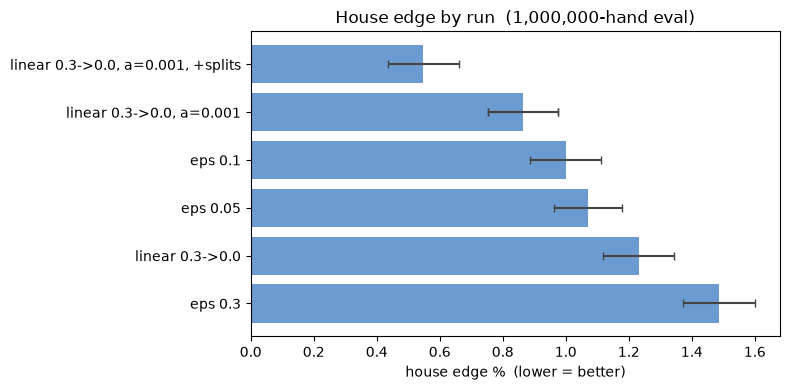

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(ledger["run"], ledger["edge_%"], xerr=ledger["se_%"], color="#6b9bd1",
        error_kw={"ecolor": "#444", "capsize": 3})
ax.invert_yaxis(); ax.set_xlabel("house edge %  (lower = better)")
ax.set_title(f"House edge by run  ({EVAL_N:,}-hand eval)")
plt.tight_layout(); plt.show()

Decay + constant-α is the best policy — but **modestly**, and the win only became visible at a large
eval: at 200k hands the ranking actually *inverted*. That is the discipline in one sentence: **rank only
on estimates whose error bars don't overlap.** The remaining gap to optimal is not an artifact of
ranking — it is real, and the rest of the notebook is about where it lives.

## 8. Convergence — how much training is enough

*Policy churn* (cells whose greedy action changed since the previous checkpoint) shows when learning has
effectively stopped. *Minimum state-visits* tracks the worst-covered cell — the coverage floor.

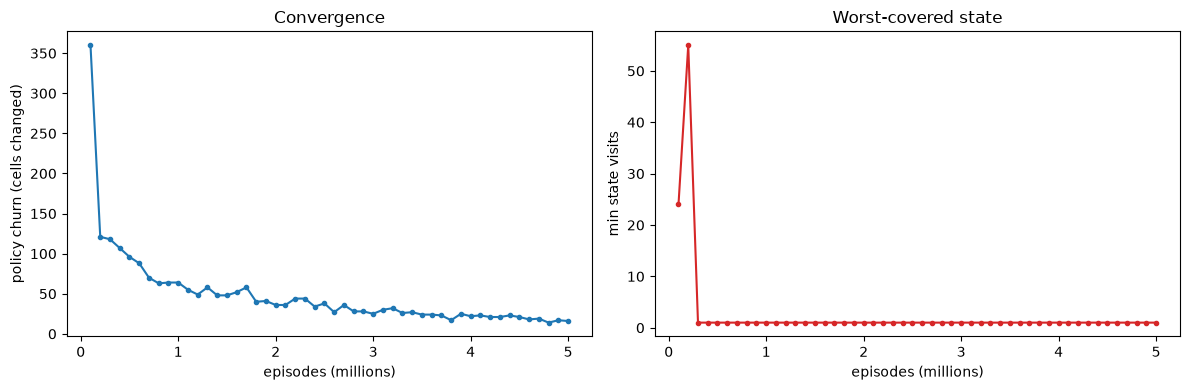

In [33]:
lc = pd.DataFrame(split["learning_curve"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(lc.episode / 1e6, lc.policy_churn, marker="o", ms=3)
ax[0].set_xlabel("episodes (millions)"); ax[0].set_ylabel("policy churn (cells changed)")
ax[0].set_title("Convergence")
ax[1].plot(lc.episode / 1e6, lc.min_state_visits, marker="o", ms=3, color="C3")
ax[1].set_xlabel("episodes (millions)"); ax[1].set_ylabel("min state visits")
ax[1].set_title("Worst-covered state")
plt.tight_layout(); plt.show()

Churn falls to a low plateau — the policy stops changing well before the last episode, so additional
training mostly refines value estimates rather than flipping decisions. But the worst-covered state
bottoms out at a *handful* of visits: even after millions of hands, the rarest cells are barely seen.
That floor is the coverage problem, stated quantitatively — and it is the through-line to the splits and
the residual below.

## 9. Completing Problem A — splits

Pairs were added by **extending the state** (a `can_split` bit) and *retraining* — not by teaching the
agent any rules. It must discover splitting from experience, like everything else. The heatmap now
carries a third panel for the pairs column.

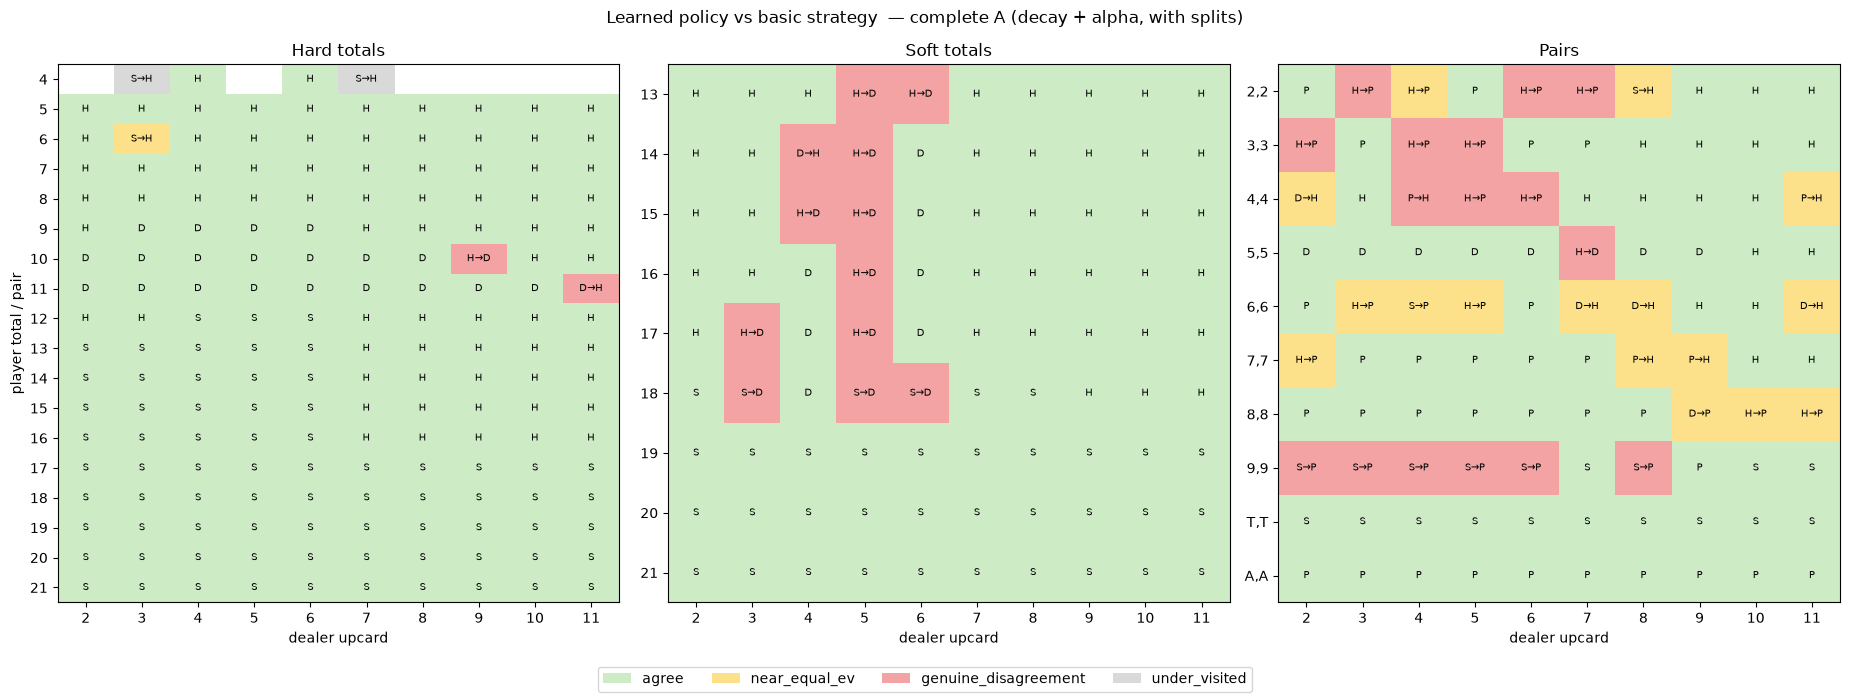

In [34]:
plot_policy_heatmap(cells_of(split), "— complete A (decay + alpha, with splits)")

In [35]:
s = cells_of(split)
dis = s[s.category != "agree"].copy()
print(f"disagreements: {len(dis)} of {len(s)} cells")
print("by category x kind:")
print(dis.groupby(["category", "kind"]).size().to_string(), "\n")
dis["cell"] = [("pair " + PAIR_LABEL.get((int(v), bool(so)), str(v))) if cs
               else (("soft " if so else "hard ") + str(v))
               for v, so, cs in zip(dis.player_value, dis.is_soft, dis.can_split)]
dis.sort_values(["category", "kind", "visits"], ascending=[True, True, False])[
    ["category", "kind", "cell", "dealer_upcard", "visits",
     "agent_action", "basic_action", "ev_gap"]].round(3)

disagreements: 49 of 364 cells
by category x kind:
category              kind
genuine_disagreement  hard     2
                      pair    16
                      soft    12
near_equal_ev         hard     1
                      pair    16
under_visited         hard     2 



,category,kind,cell,dealer_upcard,visits,agent_action,basic_action,ev_gap
98,genuine_disagreement,hard,hard 10,9,16212,hit,double,0.045
113,genuine_disagreement,hard,hard 11,11,14875,double,hit,0.072
7,genuine_disagreement,pair,"pair 2,2",6,2433,hit,split,0.029
31,genuine_disagreement,pair,"pair 3,3",5,2363,hit,split,0.026
25,genuine_disagreement,pair,"pair 3,3",2,2306,hit,split,0.021
9,genuine_disagreement,pair,"pair 2,2",7,2288,hit,split,0.039
277,genuine_disagreement,pair,"pair 9,9",8,2282,stand,split,0.112
2,genuine_disagreement,pair,"pair 2,2",3,2278,hit,split,0.026
267,genuine_disagreement,pair,"pair 9,9",3,2265,stand,split,0.136
29,genuine_disagreement,pair,"pair 3,3",4,2253,hit,split,0.036


Adding splits **improved the edge** (see the ledger): correct splitting recovers EV that a no-split
policy leaves on the table. The agent learned the bulk of the split column. Its misses are almost all
**under-splitting the rare low pairs** (2,2 / 3,3 / 4,4) and 9,9 — cells seen only ~2,300 times, where
the split *action itself* was tried far fewer. Same coverage signature as the doubling cells, now in a
new column. The non-pair disagreements are the same soft/near-tie residual we already characterized —
splits didn't change them.

## 10. The residual, honestly — the cost of learning from experience

The best agent reaches ≈ 0.5% against an optimal ≈ 0.45–0.5%: it **approaches but does not match** the
optimum. The gap is not spread across the policy — it is concentrated in the soft-double and low-pair
cells, and it decomposes into two parts:

- **Coverage (reducible).** Rare cells are rarely experienced, so their under-sampled actions stay
  mis-valued. This is the dominant part — and it is the cost of learning from experience: basic strategy
  is computed exhaustively; the agent only knows what it has *seen*.
- **Representation / near-ties (a floor).** Some disagreements are genuine ties given the state
  abstraction (e.g. hard-16-vs-10). "Wrong" costs almost nothing, and no amount of data separates them.

**The test (capstone).** If coverage is truly the dominant cause, then *forcing* coverage — exploring
starts that deal every (state, action) pair regardless of rarity — should collapse the coverage residual
and leave only the near-tie floor. The prediction is explicit and falsifiable: the experiment is
designed to *earn* the claim, not assert it. (Run and added below when complete.)

## Findings

1. **The agent rediscovers basic strategy where it matters** — near-optimal edge, hard-total play
   essentially solved.
2. **Errors are localized, not diffuse** (≈2% hard vs ≈27% doubling). Report the localization, not the
   pooled agreement.
3. **Severity matters.** Most disagreements are near-ties (including the famous hard-16-vs-10); only a
   few are real, and even those trace back to under-sampled actions.
4. **More exploration relocates the residual, it doesn't remove it** — the core tradeoff of fixed-ε
   on-policy control.
5. **Recency-weighting (decay + constant-α) wins — modestly.** Rank only on estimates whose error bars
   don't overlap; a smaller eval inverted the ranking.
6. **Splits show the same story in a new column** — most of the column learned, the rare pairs
   under-split.
7. **The residual is mostly the cost of learning from experience** — a falsifiable claim the
   exploring-starts capstone is built to test.